Notebook to see if the train images are in the correct

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [14]:
# load numpy
data_dir ="/gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/data/validate_stimulus_presentation/"
path = "/gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/data/validate_stimulus_presentation/test_18x16.npy"

In [ ]:
# load numpy array THIS IS THE LEFT EYE 
data = np.load(path)

In [ ]:
data.shape
first_frame = data[:, 0, :, :]
Green = first_frame[0, :, :]
UV = first_frame[1, :, :]

rgb_frame = np.zeros((3,18,16),dtype=np.uint8)
rgb_frame[1, :, :] = first_frame[0, :, :]  # Green channel
rgb_frame[2, :, :] = first_frame[1, :, :]  # UV channel

# transpose to (height, width, channels)
rgb_frame = rgb_frame.transpose(1, 2, 0)


bgr_frame = cv2.cvtColor(rgb_frame, cv2.COLOR_RGB2BGR)
cv2.imwrite(f"{data_dir}bgr_first_frame.jpg", bgr_frame)


bgr_frame_manual = np.zeros((18, 16, 3), dtype=np.uint8)
bgr_frame_manual[:, :, 0] = first_frame[1, :, :]  
bgr_frame_manual[:, :, 1] = first_frame[0, :, :]  

cv2.imwrite(f"{data_dir}bgr_first_frame_manual.jpg", bgr_frame_manual)


True

Text(0.5, 1.0, 'UV Channel')

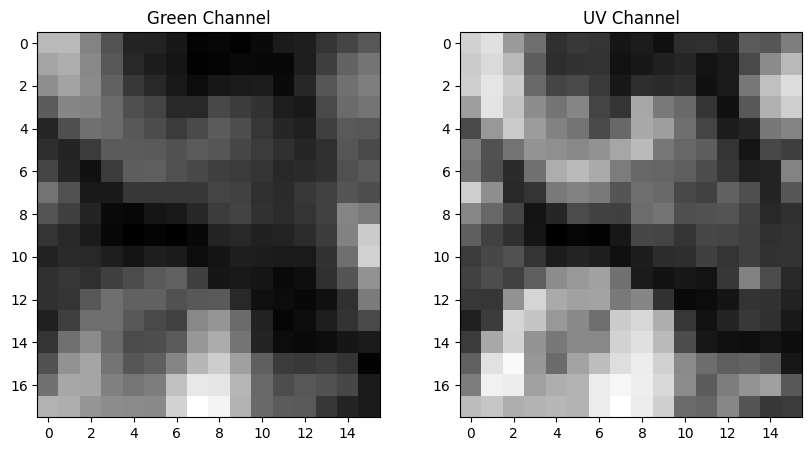

In [39]:
fig,ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(Green, cmap='gray')
ax[0].set_title('Green Channel')
ax[1].imshow(UV, cmap='gray')
ax[1].set_title('UV Channel')

Looking at the jpgs created they look just like the upsampled version of the first frame (lower left image in montage located at /mnt/cin_data/Resources/Stimulus/mouse_movie_stimulus_20200128 left test)

# compare with OR

In [16]:
from openretina.data_io.hoefling_2024.stimuli import movies_from_pickle


In [20]:
movies_path = "/gpfs01/euler/User/ssuhai/openretina_cache/euler_lab/hoefling_2024/stimuli/rgc_natstim_18x16_joint_normalized_2024-01-11.pkl"
movies_dict = movies_from_pickle(movies_path)

In [66]:
movies_dict.test_dict["test"].shape
def plot_frame_left(idx):
    first_frame = movies_dict.test_dict["test"][:, idx, :, :]
    # Green = first_frame[0, :, :]
    # UV = first_frame[1, :, :]

    # because the default is right we fllip to left
    fig,ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(np.flip(first_frame[0, :, :],axis=1), cmap='gray')
    ax[0].set_title('Green Channel')
    ax[1].imshow(np.flip(first_frame[1, :, :],axis=1), cmap='gray')
    ax[1].set_title('UV Channel')


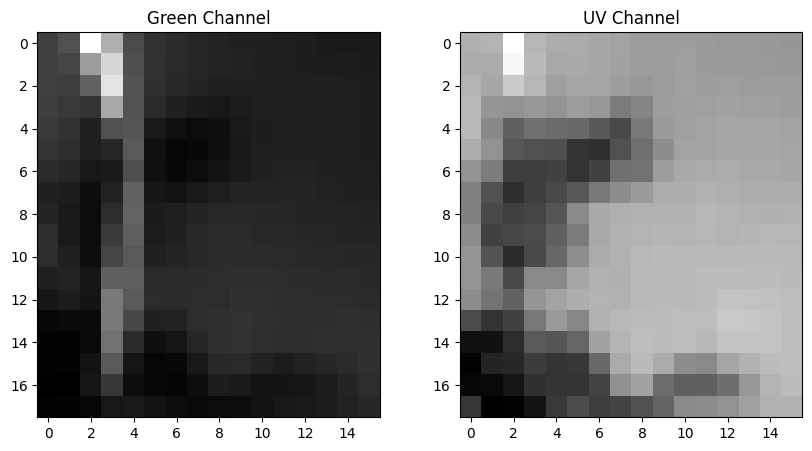

In [70]:
plot_frame_left(160)

This is also exactly the same 

In [ ]:
# because the default is right we fllip to left
fig,ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(first_frame[0, :, :], cmap='gray')
ax[0].set_title('Green Channel')
ax[1].imshow(first_frame[1, :, :], cmap='gray')
ax[1].set_title('UV Channel')

# Create test MEI avi 

In [42]:
import torch

import sys

# add repo to path
sys.path.append("/gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/")

from simulations.loop_components.stimulus import create_avi_from_tensor

In [43]:
frame1_movie2 = movies_dict.test_dict["test"][:, 150 * 1, :, :]

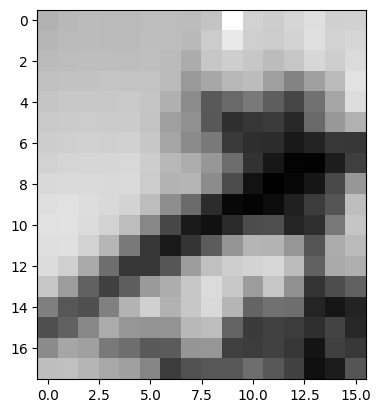

In [45]:
plt.imshow(frame1_movie2[1, :, :], cmap='gray')

In [50]:
repeated_frame = torch.tensor(frame1_movie2).unsqueeze(1).repeat(1,60, 1, 1)

# normalize to 0 255
repeated_frame = (repeated_frame - repeated_frame.min()) / (repeated_frame.max() - repeated_frame.min())
repeated_frame = (repeated_frame * 255)

create_avi_from_tensor(
    repeated_frame,
    f"{data_dir}test_movie2_frame_150_right_allch_rotated.avi",)

In [54]:
repeated_frame.shape

torch.Size([2, 60, 18, 16])

In [ ]:
create_avi_from_tensor(
    repeated_frame,
    f"{data_dir}test_movie2_frame_150_right_allch_NOTrotated.avi",
    rotate_90_cw=False,)

In [57]:
# one where all the stuff is in green channel ie 0
all_green_frame = torch.zeros_like(repeated_frame)
all_green_frame[0, :, :, :] = torch.mean(repeated_frame,dim=0).unsqueeze(0)
all_green_frame.shape

create_avi_from_tensor(
    all_green_frame,
    f"{data_dir}test_movie2_frame_150_right_all_green_NOTrotated.avi",
    rotate_90_cw=False,)


create_avi_from_tensor(
    all_green_frame,
    f"{data_dir}test_movie2_frame_150_right_all_green_rotated.avi",
    rotate_90_cw=True,)

In [58]:
# all there stuff is in UV channel ie 1
all_uv_frame = torch.zeros_like(repeated_frame)
all_uv_frame[1, :, :, :] = torch.mean(repeated_frame,dim=0).unsqueeze(0)
all_uv_frame.shape

create_avi_from_tensor(
    all_uv_frame,
    f"{data_dir}test_movie2_frame_150_right_all_uv_NOTrotated.avi",
    rotate_90_cw=False,)

create_avi_from_tensor(
    all_uv_frame,
    f"{data_dir}test_movie2_frame_150_right_all_uv_rotated.avi",
    rotate_90_cw=True,)